# Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim_metric


# Configuration

In [16]:
from pathlib import Path
BASE_DIR = Path.cwd()
CONFIG = {
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',

    'noise_levels': [0.1, 0.2, 0.3],

    'tsne': {
        'n_samples': 1000,
        'perplexity': 30
    },

    'datasets': {
        'fashion': {
            'path': 'FashionMNIST',
            'checkpoint':  BASE_DIR.parent.parent / 'Trained_fashion_model' / 'best_model.pth',
            'batch_size': 16,
            'class_names': [
                'T-shirt/top',
                'Trouser',
                'Pullover',
                'Dress',
                'Coat',
                'Sandal',
                'Shirt',
                'Sneaker',
                'Bag',
                'Ankle boot'
            ]
        },

        'xray': {
            'path': BASE_DIR.parent.parent / 'Trained_xray_model' / 'test',
            'checkpoint':  BASE_DIR.parent.parent / 'Trained_xray_model' / 'best_model.pth',
            'batch_size': 8,
            'class_names': [
                'NORMAL',
                'PNEUMONIA'
            ]
        }
    }
}


# Dataset Helpers

In [4]:
def get_transforms(dataset_name):
    transform_list = [
        transforms.Resize((128, 128)),
    ]

    if dataset_name == 'xray':
        transform_list.append(
            transforms.Grayscale(num_output_channels=1)
        )

    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    return transforms.Compose(transform_list)


def get_dataset(dataset_name, split='test'):
    config = CONFIG['datasets'][dataset_name]

    transform = get_transforms(dataset_name)

    if dataset_name == 'fashion':
        dataset = datasets.FashionMNIST(
            root=config['path'],
            train=False,
            transform=transform,
            download=True
        )

    elif dataset_name == 'xray':
        dataset = datasets.ImageFolder(
            root=config['path'],
            transform=transform
        )

    else:
        raise ValueError(f'Unsupported dataset: {dataset_name}')

    return dataset


def get_loader(dataset_name, split='test'):
    config = CONFIG['datasets'][dataset_name]

    dataset = get_dataset(dataset_name, split)

    loader = DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=False
    )

    return loader, dataset


# Model

In [5]:
# Define the autoencoder architecture
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 5, stride=1, padding=2),
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(16, 8, 5, stride=1, padding=2),
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 2, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Use CPU for evaluation to prevent kernel crashes from GPU memory or driver issues.
# If you want GPU, change this back after confirming stability.
device = torch.device('cpu')

# Evaluation Helpers

In [6]:
def add_gaussian_noise(images, sigma=0.2):
    noise = torch.randn_like(images) * sigma

    noisy_images = images + noise

    return torch.clamp(noisy_images, -1.0, 1.0)


def compute_ssim_batch(predictions, targets):
    predictions = ((predictions + 1.0) / 2.0).cpu().numpy()
    targets = ((targets + 1.0) / 2.0).cpu().numpy()

    total_ssim = 0.0

    for i in range(predictions.shape[0]):
        total_ssim += ssim_metric(
            predictions[i, 0],
            targets[i, 0],
            data_range=1.0
        )

    return total_ssim / predictions.shape[0]


def compute_psnr(mse_value):
    return 20 * np.log10(1.0 / np.sqrt(mse_value + 1e-10))


# Model Evaluation

In [7]:
def evaluate_model(dataset_name):
    config = CONFIG['datasets'][dataset_name]

    device = torch.device(CONFIG['device'])

    loader, _ = get_loader(dataset_name)

    model = autoencoder().to(device)

    checkpoint = torch.load(
        config['checkpoint'],
        map_location=device
    )
    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    results = {}

    for sigma in CONFIG['noise_levels']:

        total_mse = 0.0
        total_ssim = 0.0
        total_images = 0

        with torch.no_grad():
            for images, _ in loader:

                images = images.to(device)

                noisy_images = add_gaussian_noise(images, sigma)

                outputs = model(noisy_images)

                mse = F.mse_loss(outputs, images).item()
                ssim = compute_ssim_batch(outputs, images)

                batch_size = images.size(0)

                total_mse += mse * batch_size
                total_ssim += ssim * batch_size
                total_images += batch_size

        avg_mse = total_mse / total_images
        avg_ssim = total_ssim / total_images
        avg_psnr = compute_psnr(avg_mse)

        results[sigma] = {
            'MSE': avg_mse,
            'SSIM': avg_ssim,
            'PSNR': avg_psnr
        }

    return results


# Latent Space Analysis

In [8]:
def extract_encodings(dataset_name, n_samples=1000):
    config = CONFIG['datasets'][dataset_name]

    device = torch.device(CONFIG['device'])

    loader, dataset = get_loader(dataset_name)

    model = autoencoder().to(device)

    checkpoint = torch.load(
        config['checkpoint'],
        map_location=device
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    all_encodings = []
    all_labels = []

    samples_processed = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            encoded = model.encoder(images)

            encoded = encoded.view(encoded.size(0), -1)

            all_encodings.append(encoded.cpu().numpy())
            all_labels.append(labels.numpy())

            samples_processed += images.size(0)

            if samples_processed >= n_samples:
                break

    encodings = np.concatenate(all_encodings, axis=0)[:n_samples]
    labels = np.concatenate(all_labels, axis=0)[:n_samples]

    labels = labels.astype(int)

    return encodings, labels


import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px
import matplotlib.pyplot as plt

def plot_tsne_2d(
    dataset_name,
    encodings,
    labels,
    class_names,
    save_static_path=None
):

    tsne = TSNE(
        n_components=2,
        perplexity=CONFIG['tsne']['perplexity'],
        random_state=42
    )

    embeddings = tsne.fit_transform(encodings)
    labels = labels.astype(int)

    df = pd.DataFrame({
        'x': embeddings[:, 0],
        'y': embeddings[:, 1],
        'label': labels,
        'class_name': [class_names[i] for i in labels]
    })

    # =========================
    # STATIC PLOT (Matplotlib)
    # =========================
    plt.figure(figsize=(8, 6))

    for class_id, class_name in enumerate(class_names):
        subset = df[df['label'] == class_id]
        plt.scatter(subset['x'], subset['y'], label=class_name, alpha=0.7)

    plt.title(f"t-SNE 2D (Static) - {dataset_name}")
    plt.legend()

    if save_static_path:
        plt.savefig(save_static_path, dpi=300, bbox_inches='tight')

    plt.show()

    # =========================
    # INTERACTIVE PLOT (Plotly)
    # =========================
    fig = px.scatter(
        df,
        x='x',
        y='y',
        color='class_name',
        opacity=0.7,
        title=f'Interactive 2D t-SNE - {dataset_name}'
    )

    fig.update_traces(marker=dict(size=6))
    fig.show()


def plot_tsne_3d(
    dataset_name,
    encodings,
    labels,
    class_names,
    save_static_path=None
):

    tsne = TSNE(
        n_components=3,
        perplexity=CONFIG['tsne']['perplexity'],
        random_state=42
    )

    embeddings = tsne.fit_transform(encodings)
    labels = labels.astype(int)

    df = pd.DataFrame({
        'x': embeddings[:, 0],
        'y': embeddings[:, 1],
        'z': embeddings[:, 2],
        'label': labels,
        'class_name': [class_names[i] for i in labels]
    })

    # =========================
    # STATIC 3D (Matplotlib)
    # =========================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    for class_id, class_name in enumerate(class_names):
        subset = df[df['label'] == class_id]
        ax.scatter(subset['x'], subset['y'], subset['z'], label=class_name, alpha=0.7)

    ax.set_title(f"t-SNE 3D (Static) - {dataset_name}")
    ax.legend()

    if save_static_path:
        plt.savefig(save_static_path, dpi=300, bbox_inches='tight')

    plt.show()

    # =========================
    # INTERACTIVE 3D (Plotly)
    # =========================
    fig = px.scatter_3d(
        df,
        x='x',
        y='y',
        z='z',
        color='class_name',
        opacity=0.7,
        title=f'Interactive 3D t-SNE - {dataset_name}'
    )

    fig.update_traces(marker=dict(size=4))
    fig.show()

# Results Table

In [9]:
def create_results_table(results):
    rows = []

    for sigma, metrics in results.items():
        rows.append({
            'Noise Sigma': sigma,
            'MSE': metrics['MSE'],
            'SSIM': metrics['SSIM'],
            'PSNR': metrics['PSNR']
        })

    return pd.DataFrame(rows)


In [10]:
import os

print(os.getcwd())

c:\ASU\Masters\Machine Learning\Project\Project_4\Evaluation\Baseline


# FashionMNIST Evaluation

In [11]:
print('=== FashionMNIST Evaluation ===')

fashion_results = evaluate_model('fashion')

fashion_df = create_results_table(fashion_results)

fashion_df


=== FashionMNIST Evaluation ===


,Noise Sigma,MSE,SSIM,PSNR
0,0.1,0.001000,0.957635,30.001468
1,0.2,0.001622,0.926316,27.898804
2,0.3,0.002770,0.844691,25.575961


# FashionMNIST t-SNE

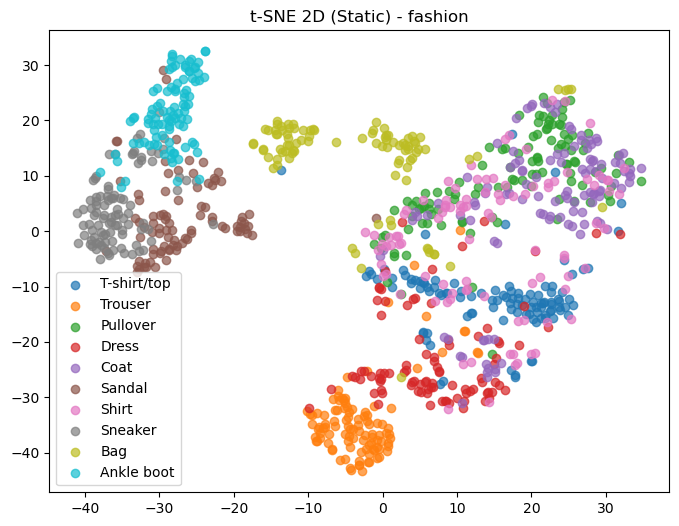

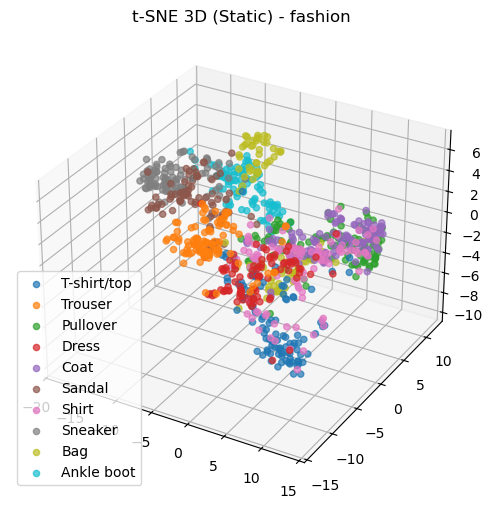

In [13]:
encodings_fashion, labels_fashion = extract_encodings(
    'fashion',
    n_samples=1000
)

plot_tsne_2d(
    'fashion',
    encodings_fashion,
    labels_fashion,
    CONFIG['datasets']['fashion']['class_names']
)

plot_tsne_3d(
    'fashion',
    encodings_fashion,
    labels_fashion,
    CONFIG['datasets']['fashion']['class_names']
)


# X-Ray Evaluation

In [17]:
print('=== X-Ray Evaluation ===')

xray_results = evaluate_model('xray')

xray_df = create_results_table(xray_results)

xray_df


=== X-Ray Evaluation ===


,Noise Sigma,MSE,SSIM,PSNR
0,0.1,0.004334,0.860440,23.631300
1,0.2,0.005241,0.821950,22.805489
2,0.3,0.007346,0.763237,21.339711


# X-Ray t-SNE

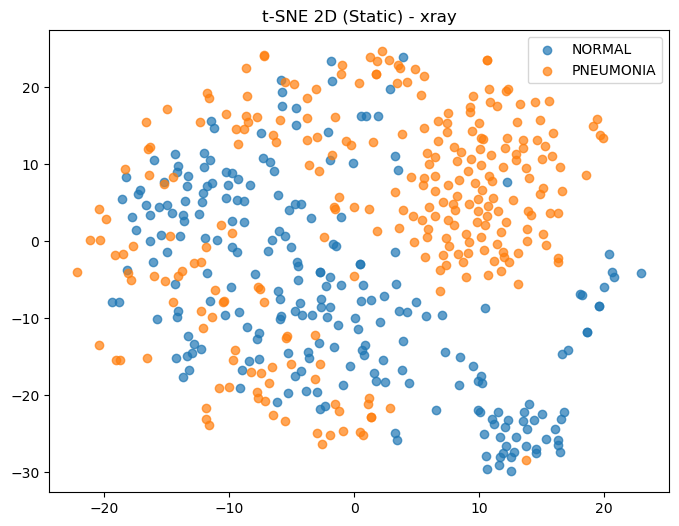

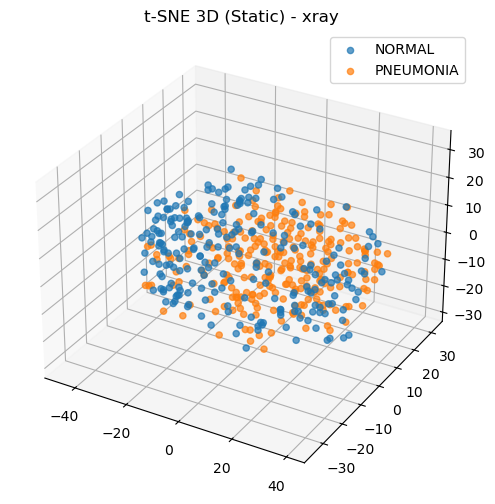

In [18]:
encodings_xray, labels_xray = extract_encodings(
    'xray',
    n_samples=500
)

plot_tsne_2d(
    'xray',
    encodings_xray,
    labels_xray,
    CONFIG['datasets']['xray']['class_names']
)

plot_tsne_3d(
    'xray',
    encodings_xray,
    labels_xray,
    CONFIG['datasets']['xray']['class_names']
)
